# VN-Index + SVI Daily Pipeline

Notebook này được viết lại từ đầu theo 3 phase rõ ràng: Load data, Data engineer, EDA. Mục tiêu là một daily panel từ 2010 đến 2025, dùng cache-first cho Google Trends, và một file cuối cùng trong `data/` được bảo vệ bởi cờ overwrite.

## Phase 0. Setup

Trước khi đi vào mô hình, cần khóa chặt chất lượng dữ liệu gốc. VN-Index đóng vai trò lịch giao dịch chuẩn, còn Google Trends được lấy theo từng cửa sổ có overlap để giảm rủi ro 429 và giữ chuỗi nhất quán theo thời gian.

### Import libraries and set constants

In [ ]:
import json
import sys
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import vnstock as vns
from IPython.display import display
from pandas.errors import EmptyDataError
from pytrends.exceptions import TooManyRequestsError
from pytrends.request import TrendReq
from sklearn.decomposition import PCA
from statsmodels.tsa.ar_model import AutoReg

warnings.filterwarnings("ignore")

In [ ]:
@dataclass
class DataConfig:
    symbol: str = "VNINDEX"
    fallback_symbols: Tuple[str, ...] = ("VN-INDEX", "VNI")
    price_source: str = "VCI"
    start_date: str = "2010-01-01"
    end_date: str = "2025-12-31"
    keywords: Tuple[str, ...] = ("chung khoan", "VN-Index", "co phieu", "dau tu")
    geo: str = "VN"
    hl: str = "en-US"
    tz: int = 420

    trend_window_days: int = 240
    trend_overlap_days: int = 14
    trend_sleep_seconds: float = 8.0
    trend_max_retries: int = 5
    trend_backoff_base_seconds: float = 5.0
    trend_backoff_max_seconds: float = 10.0
    api_sleep_seconds: float = 1.5
    api_max_retries: int = 4
    api_backoff_base_seconds: float = 2.0
    api_backoff_max_seconds: float = 30.0

    cache_dir: str = "outputs/trends_cache"
    data_dir: str = "data"
    final_filename: str = "final_data.csv"

    update_final_file: bool = False


CONFIG = DataConfig()
OUTPUT_DIR = Path(CONFIG.data_dir)
CACHE_DIR = Path(CONFIG.cache_dir)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
# print(json.dumps(asdict(CONFIG), indent=2))

Python: 3.11.4
pandas: 3.0.0
numpy: 2.4.1


### Helper functions

In [28]:
def get_active_date_range(config: DataConfig) -> Tuple[pd.Timestamp, pd.Timestamp]:
    return pd.Timestamp(config.start_date), pd.Timestamp(config.end_date)


def _sleep_with_backoff(attempt: int, base_seconds: float, max_seconds: float) -> None:
    wait_seconds = min(base_seconds * (2 ** max(0, attempt - 1)), max_seconds)
    time.sleep(wait_seconds)


def _normalize_datetime_index(index: pd.Index) -> pd.DatetimeIndex:
    dt_index = pd.to_datetime(index)
    if getattr(dt_index, "tz", None) is not None:
        dt_index = dt_index.tz_localize(None)
    return pd.DatetimeIndex(dt_index)


def _api_call_with_retry(call_fn, *, call_name: str, max_retries: int, base_backoff: float, max_backoff: float):
    last_error: Optional[Exception] = None
    for attempt in range(1, max_retries + 1):
        try:
            return call_fn()
        except Exception as exc:
            last_error = exc
            if attempt == max_retries:
                break
            _sleep_with_backoff(attempt, base_backoff, max_backoff)
    raise RuntimeError(f"API call failed after retries: {call_name}") from last_error


def _normalize_price_frame(df: pd.DataFrame, config: DataConfig, symbol_used: str) -> pd.DataFrame:
    lowered = {col.lower(): col for col in df.columns}
    date_col = lowered.get("time") or lowered.get("date") or lowered.get("datetime")
    close_col = lowered.get("close") or lowered.get("adj close") or lowered.get("adj_close")
    if date_col is None or close_col is None:
        raise ValueError(f"Unexpected vnstock columns: {list(df.columns)}")

    out = df[[date_col, close_col]].copy()
    out.columns = ["date", "close"]
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out["close"] = pd.to_numeric(out["close"], errors="coerce")
    out = out.dropna(subset=["date", "close"])
    out = out.set_index("date").sort_index()
    out = out.loc[(out.index >= pd.Timestamp(config.start_date)) & (out.index <= pd.Timestamp(config.end_date))]
    out["symbol_used"] = symbol_used
    out.index.name = "date"
    return out


def _download_vnindex(symbol: str, config: DataConfig) -> pd.DataFrame:
    start_ts, end_ts = get_active_date_range(config)
    start_str = start_ts.strftime("%Y-%m-%d")
    end_str = end_ts.strftime("%Y-%m-%d")

    def legacy_loader() -> pd.DataFrame:
        return vns.stock_historical_data(
            symbol=symbol,
            start_date=start_str,
            end_date=end_str,
            resolution="1D",
            type="index",
            source=config.price_source,
            beautify=False,
            decor=False,
        )

    def legacy_fallback_loader() -> pd.DataFrame:
        return vns.stock_historical_data(
            symbol=symbol,
            start_date=start_str,
            end_date=end_str,
            resolution="1D",
            type="index",
        )

    def new_api_loader() -> pd.DataFrame:
        client = vns.Vnstock()
        quote = client.stock(symbol=symbol, source=config.price_source).quote
        return quote.history(start=start_str, end=end_str, interval="1D")

    if hasattr(vns, "stock_historical_data"):
        try:
            hist = _api_call_with_retry(
                legacy_loader,
                call_name=f"vnstock.stock_historical_data({symbol})",
                max_retries=config.api_max_retries,
                base_backoff=config.api_backoff_base_seconds,
                max_backoff=config.api_backoff_max_seconds,
            )
            time.sleep(config.api_sleep_seconds)
            if isinstance(hist, pd.DataFrame) and not hist.empty:
                return hist
        except TypeError:
            hist = _api_call_with_retry(
                legacy_fallback_loader,
                call_name=f"vnstock.stock_historical_data fallback({symbol})",
                max_retries=config.api_max_retries,
                base_backoff=config.api_backoff_base_seconds,
                max_backoff=config.api_backoff_max_seconds,
            )
            time.sleep(config.api_sleep_seconds)
            if isinstance(hist, pd.DataFrame) and not hist.empty:
                return hist

    if hasattr(vns, "Vnstock"):
        hist = _api_call_with_retry(
            new_api_loader,
            call_name=f"vnstock.Vnstock().quote.history({symbol})",
            max_retries=config.api_max_retries,
            base_backoff=config.api_backoff_base_seconds,
            max_backoff=config.api_backoff_max_seconds,
        )
        time.sleep(config.api_sleep_seconds)
        if isinstance(hist, pd.DataFrame) and not hist.empty:
            return hist

    return pd.DataFrame()


def fetch_vnindex_prices(config: DataConfig) -> pd.DataFrame:
    candidates = [config.symbol] + [symbol for symbol in config.fallback_symbols if symbol != config.symbol]
    errors: List[str] = []

    for symbol in candidates:
        try:
            raw = _download_vnindex(symbol, config)
            if raw.empty:
                errors.append(f"{symbol}: empty dataframe")
                continue
            out = _normalize_price_frame(raw, config, symbol)
            if out.empty:
                errors.append(f"{symbol}: empty after cleaning")
                continue
            return out
        except Exception as exc:
            errors.append(f"{symbol}: {type(exc).__name__} - {exc}")

    raise ValueError("No VN-Index data returned from vnstock. " + " | ".join(errors))


def _trend_cache_path(config: DataConfig, keyword: str, start_ts: pd.Timestamp, end_ts: pd.Timestamp) -> Path:
    safe_keyword = "".join(ch if ch.isalnum() else "_" for ch in keyword)
    filename = f"{safe_keyword}_{start_ts.strftime('%Y%m%d')}_{end_ts.strftime('%Y%m%d')}.csv"
    return Path(config.cache_dir) / filename


def build_date_windows(start_ts: pd.Timestamp, end_ts: pd.Timestamp, window_days: int, overlap_days: int) -> List[Tuple[pd.Timestamp, pd.Timestamp]]:
    if overlap_days >= window_days:
        raise ValueError("overlap_days must be smaller than window_days")

    windows: List[Tuple[pd.Timestamp, pd.Timestamp]] = []
    step = window_days - overlap_days
    current_start = start_ts

    while current_start <= end_ts:
        current_end = min(current_start + pd.Timedelta(days=window_days - 1), end_ts)
        windows.append((current_start, current_end))
        if current_end >= end_ts:
            break
        current_start = current_start + pd.Timedelta(days=step)

    return windows


def stitch_overlapping_series(chunks: List[pd.Series]) -> pd.Series:
    if not chunks:
        return pd.Series(dtype=float)

    stitched = chunks[0].copy()
    for next_series in chunks[1:]:
        overlap_index = stitched.index.intersection(next_series.index)
        if len(overlap_index) > 0:
            prev_mean = stitched.loc[overlap_index].replace(0, np.nan).mean()
            next_mean = next_series.loc[overlap_index].replace(0, np.nan).mean()
            factor = prev_mean / next_mean if pd.notna(prev_mean) and pd.notna(next_mean) and next_mean > 0 else 1.0
        else:
            factor = 1.0
        scaled_next = next_series * factor
        stitched = pd.concat([stitched, scaled_next[~scaled_next.index.isin(stitched.index)]])
        stitched = stitched.sort_index()

    return stitched


def fetch_trend_window(pytrends: TrendReq, keyword: str, start_ts: pd.Timestamp, end_ts: pd.Timestamp, config: DataConfig) -> pd.Series:
    cache_path = _trend_cache_path(config, keyword, start_ts, end_ts)
    if cache_path.exists():
        try:
            cached = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        except EmptyDataError:
            cached = pd.DataFrame()
        if not cached.empty and keyword in cached.columns:
            series = cached[keyword].astype(float)
            series.index = _normalize_datetime_index(series.index)
            series.name = keyword
            return series

    timeframe = f"{start_ts.strftime('%Y-%m-%d')} {end_ts.strftime('%Y-%m-%d')}"
    for attempt in range(1, config.trend_max_retries + 1):
        try:
            pytrends.build_payload([keyword], timeframe=timeframe, geo=config.geo)
            data = pytrends.interest_over_time()
            time.sleep(config.trend_sleep_seconds)
            if data.empty or keyword not in data.columns:
                return pd.Series(dtype=float, name=keyword)
            series = data[keyword].astype(float)
            series.index = _normalize_datetime_index(series.index)
            series.name = keyword
            pd.DataFrame({keyword: series}).to_csv(cache_path)
            return series
        except TooManyRequestsError:
            if attempt == config.trend_max_retries:
                raise RuntimeError(f"Google Trends rate limit persisted for {keyword} in {timeframe}")
            wait_seconds = min(config.trend_backoff_base_seconds * (2 ** (attempt - 1)), config.trend_backoff_max_seconds)
            print(f"429 for {keyword} [{timeframe}] attempt {attempt}/{config.trend_max_retries}, waiting {wait_seconds:.1f}s")
            time.sleep(wait_seconds)

    return pd.Series(dtype=float, name=keyword)


def fetch_keyword_series(config: DataConfig, keyword: str) -> pd.Series:
    start_ts, end_ts = get_active_date_range(config)
    windows = build_date_windows(start_ts, end_ts, config.trend_window_days, config.trend_overlap_days)
    pytrends = TrendReq(hl=config.hl, tz=config.tz)

    chunks: List[pd.Series] = []
    for window_start, window_end in windows:
        series = fetch_trend_window(pytrends, keyword, window_start, window_end, config)
        if not series.empty:
            chunks.append(series)

    stitched = stitch_overlapping_series(chunks)
    stitched.name = keyword
    stitched = stitched.loc[(stitched.index >= start_ts) & (stitched.index <= end_ts)]
    return stitched


def build_keyword_panel(config: DataConfig) -> pd.DataFrame:
    keyword_series = {keyword: fetch_keyword_series(config, keyword) for keyword in config.keywords}
    keyword_df = pd.DataFrame(keyword_series).sort_index()
    keyword_df.index.name = "date"
    return keyword_df


def build_svi_from_keywords(keyword_df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, object]]:
    if keyword_df.empty:
        raise ValueError("No Google Trends data loaded.")

    standardized = (keyword_df - keyword_df.mean()) / keyword_df.std(ddof=0)
    standardized = standardized.replace([np.inf, -np.inf], np.nan).dropna(how="any")
    if standardized.empty:
        raise ValueError("No valid rows remain after keyword standardization.")

    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(standardized.values).reshape(-1)
    svi = pd.Series(pc1, index=standardized.index, name="SVI")

    reference = standardized.mean(axis=1)
    common_index = svi.index.intersection(reference.index)
    if len(common_index) > 10 and svi.loc[common_index].corr(reference.loc[common_index]) < 0:
        svi = -svi

    svi = svi.rolling(3, min_periods=1).mean()
    svi_df = pd.DataFrame({"SVI": svi}).sort_index()
    meta = {
        "explained_variance_ratio": float(pca.explained_variance_ratio_[0]),
        "pc1_loadings": pd.Series(pca.components_[0], index=standardized.columns).sort_values(ascending=False).to_dict(),
    }
    return svi_df, meta


def build_raw_panel(config: DataConfig) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, Dict[str, object]]:
    price_df = fetch_vnindex_prices(config)
    keyword_df = build_keyword_panel(config)
    svi_df, svi_meta = build_svi_from_keywords(keyword_df)
    panel = price_df.join(keyword_df, how="left").join(svi_df, how="left")
    panel.index.name = "date"
    return price_df, keyword_df, panel, svi_meta


def summarize_data(df: pd.DataFrame, name: str) -> pd.Series:
    summary = pd.Series({
        "name": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_index": int(df.index.duplicated().sum()),
        "start": df.index.min(),
        "end": df.index.max(),
    })
    print(summary.to_string())
    return summary


def check_basic_quality(df: pd.DataFrame, name: str) -> None:
    print(f"\nQuality check for {name}")
    summarize_data(df, name)
    if df.index.duplicated().any():
        raise ValueError(f"Duplicated index values found in {name}")

## Phase 1. Data loading rationale

Ở bước này, ta chỉ tạo panel dữ liệu thô và kiểm tra chất lượng nền. Về mặt kinh tế lượng, đây là bước xác nhận lịch giao dịch, mức độ khớp thời gian của chuỗi, và việc dữ liệu có đủ sạch để đi vào các phép biến đổi phi tuyến như PCA và lagging hay không.

In [29]:
price_df, keyword_df, raw_panel, svi_meta = build_raw_panel(CONFIG)

check_basic_quality(price_df, "vnindex_prices")
check_basic_quality(keyword_df, "google_trends_keywords")
check_basic_quality(raw_panel, "raw_merged_panel")

display(price_df.head())
display(keyword_df.head())
display(pd.Series(svi_meta, name="svi_meta"))

missing_by_column = raw_panel.isna().sum().sort_values(ascending=False)
print("Missing values by column:\n", missing_by_column.to_string())
print("\nDuplicate index count:", int(raw_panel.index.duplicated().sum()))

2026-04-06 21:38:19 - vnstock.common.data - INFO - Not a stock. Company and finance data unavailable.



Quality check for vnindex_prices
name                    vnindex_prices
rows                              3993
columns                              2
missing_values                       0
duplicate_index                      0
start              2010-01-04 00:00:00
end                2025-12-31 00:00:00

Quality check for google_trends_keywords
name               google_trends_keywords
rows                                 5844
columns                                 4
missing_values                          0
duplicate_index                         0
start                 2010-01-01 00:00:00
end                   2025-12-31 00:00:00

Quality check for raw_merged_panel
name                  raw_merged_panel
rows                              3993
columns                              7
missing_values                       0
duplicate_index                      0
start              2010-01-04 00:00:00
end                2025-12-31 00:00:00


,close,symbol_used
date,,
2010-01-04,517.1,VNINDEX
2010-01-05,532.5,VNINDEX
2010-01-06,534.5,VNINDEX
2010-01-07,533.3,VNINDEX
2010-01-08,520.9,VNINDEX


,chung khoan,VN-Index,co phieu,dau tu
date,,,,
2010-01-01,28.0,0.0,0.0,37.0
2010-01-02,22.0,0.0,0.0,39.0
2010-01-03,21.0,0.0,37.0,43.0
2010-01-04,81.0,0.0,59.0,67.0
2010-01-05,93.0,0.0,48.0,65.0


explained_variance_ratio                                             0.528394
pc1_loadings                {'chung khoan': 0.6511730774830702, 'dau tu': ...
Name: svi_meta, dtype: object

Missing values by column:
 close          0
symbol_used    0
chung khoan    0
VN-Index       0
co phieu       0
dau tu         0
SVI            0

Duplicate index count: 0


## Phase 2. Data engineer

Sau khi dữ liệu gốc đã khớp thời gian, ta tạo các biến kinh tế lượng cốt lõi cho modeling ở file sau. Ở notebook này, phase engineer chỉ tập trung tạo bộ biến nền (`return`, `target`, `SVI`, `SVI_pos`, `SVI_neg`) và xuất `final_data` gọn, chưa thực hiện chọn độ trễ.

In [30]:
def engineer_daily_dataset(panel: pd.DataFrame) -> pd.DataFrame:
    df = panel.copy().sort_index()
    df["return"] = 100.0 * np.log(df["close"] / df["close"].shift(1))
    df["target"] = df["return"] ** 2
    df["SVI_pos"] = df["SVI"] * df["return"].clip(lower=0)
    df["SVI_neg"] = df["SVI"] * (-df["return"].clip(upper=0))

    final_df = df[["close", "return", "target", "SVI", "SVI_pos", "SVI_neg"]].dropna().copy()
    final_df.index.name = "date"
    return final_df


def export_final_dataset(df: pd.DataFrame, config: DataConfig) -> Path:
    final_path = Path(config.data_dir) / config.final_filename
    if final_path.exists() and not config.update_final_file:
        print(f"Skip overwrite for existing file: {final_path}")
        return final_path

    df.to_csv(final_path, index=True)
    print(f"Saved final dataset to: {final_path}")
    return final_path


final_df = engineer_daily_dataset(raw_panel)
final_path = export_final_dataset(final_df, CONFIG)

print("Final shape:", final_df.shape)
print("Final columns:", list(final_df.columns))
display(final_df.head())

Saved final dataset to: data\final_data.csv
Final shape: (3992, 6)
Final columns: ['close', 'return', 'target', 'SVI', 'SVI_pos', 'SVI_neg']


,close,return,target,SVI,SVI_pos,SVI_neg
date,,,,,,
2010-01-05,532.5,2.934662,8.612240,4.986535,14.633793,-0.000000
2010-01-06,534.5,0.374883,0.140537,6.631942,2.486204,-0.000000
2010-01-07,533.3,-0.224761,0.050518,6.720395,0.000000,1.510485
2010-01-08,520.9,-2.352603,5.534742,6.871988,0.000000,16.167061
2010-01-11,515.1,-1.119703,1.253734,4.530968,0.000000,5.073338


## Phase 3. EDA

Giai đoạn EDA không nhằm tối ưu mô hình, mà kiểm tra xem chuỗi có đúng trực giác kinh tế lượng hay không: keyword có đồng biến hay không, return có cụm biến động hay không, SVI có đi cùng proxy volatility hay không, và tác động của SVI khi return dương/âm có khác nhau hay không.

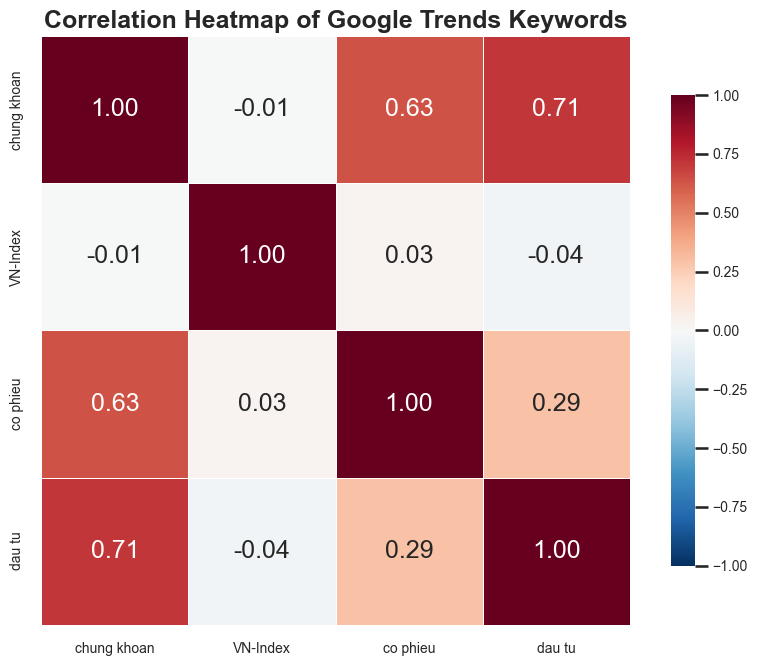

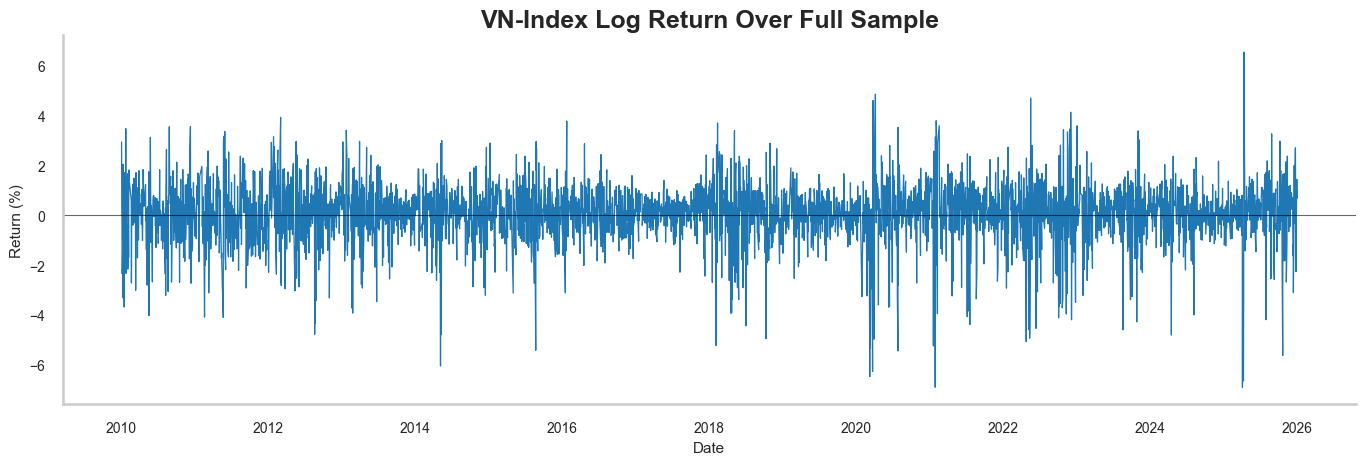

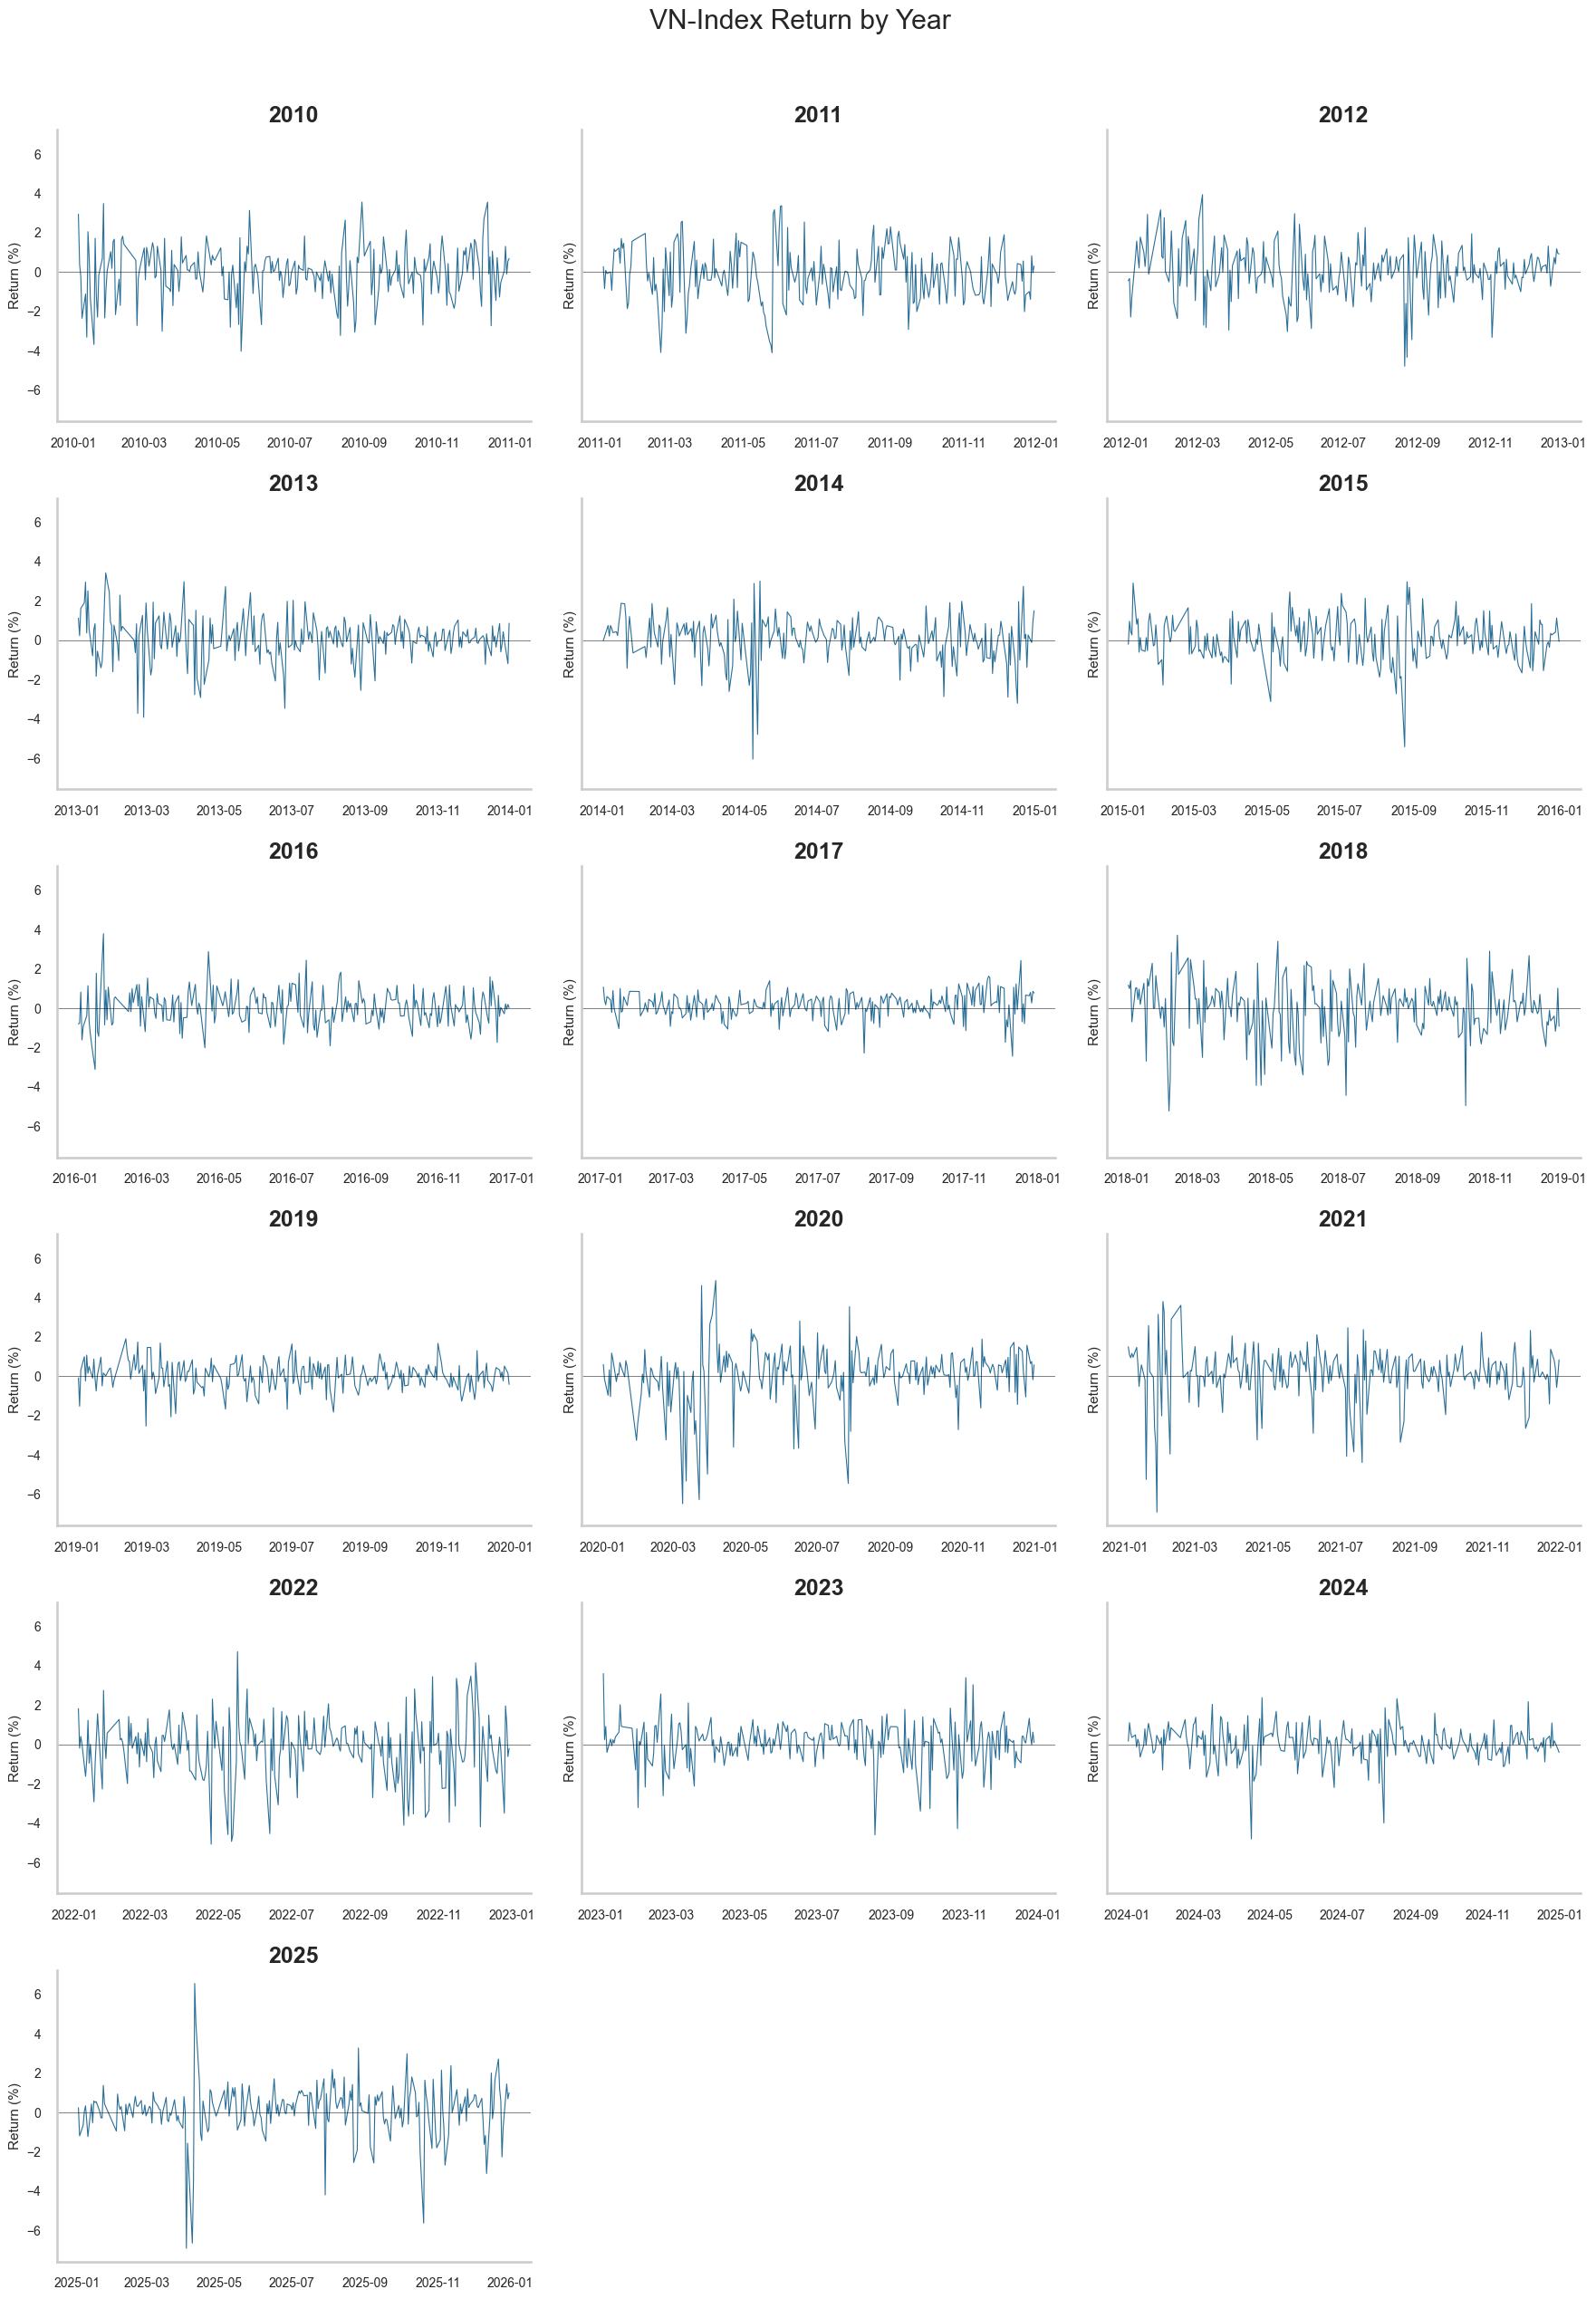

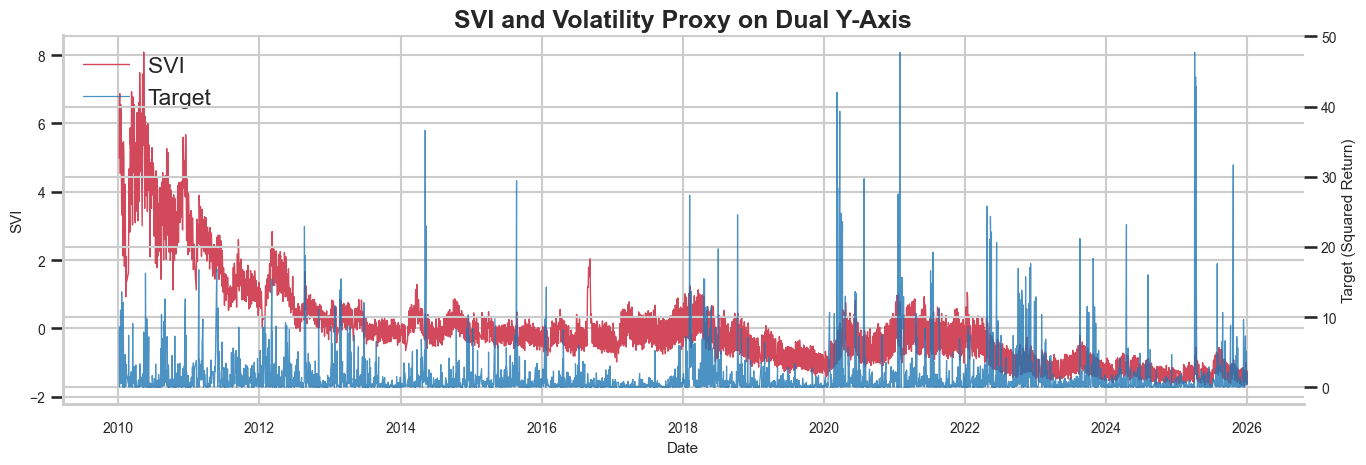

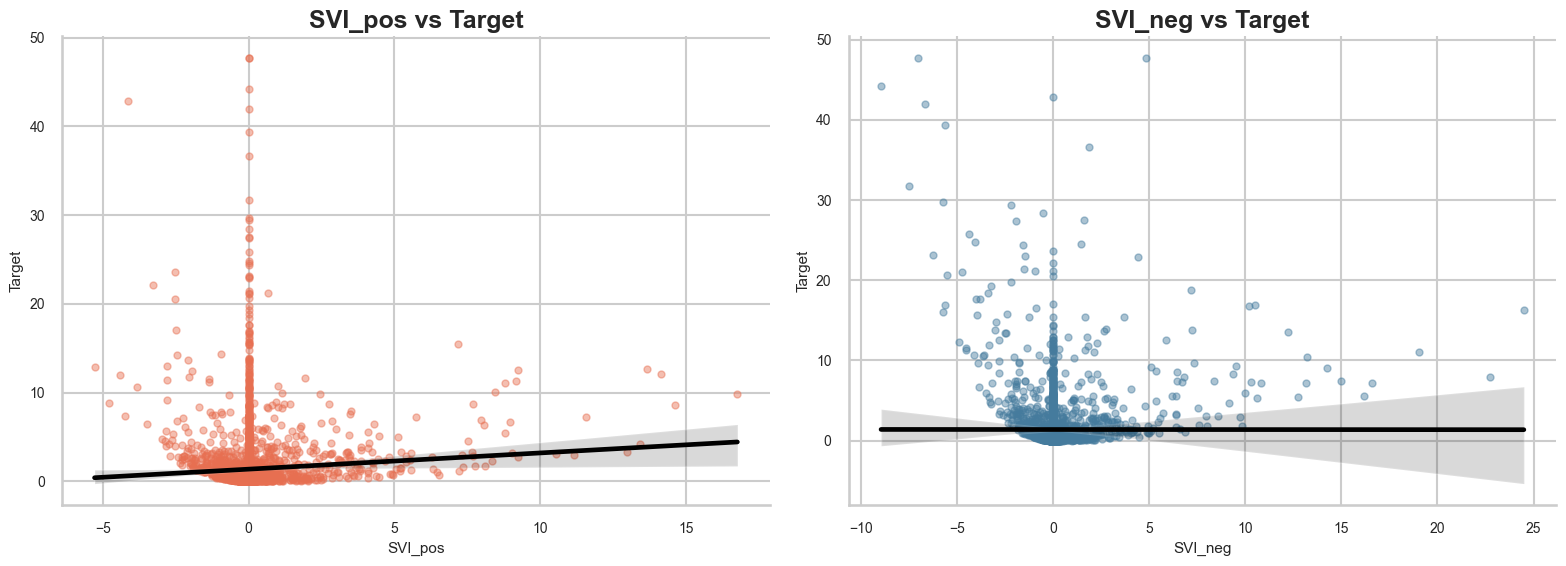

In [36]:
def _set_scientific_plot_style() -> None:
    sns.set_theme(style="whitegrid", context="talk")
    plt.rcParams.update({
        "figure.figsize": (12, 6),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
    })


def plot_keyword_correlation_heatmap(keyword_df: pd.DataFrame) -> None:
    _set_scientific_plot_style()
    corr = keyword_df.corr(method="pearson")
    _, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(
        corr,
        ax=ax,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title("Correlation Heatmap of Google Trends Keywords")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


def plot_return_series(df: pd.DataFrame) -> None:
    _set_scientific_plot_style()
    _, ax = plt.subplots(figsize=(14, 5))
    ax.grid(False)
    ax.plot(df.index, df["return"], color="#1f77b4", linewidth=0.9)
    ax.set_title("VN-Index Log Return Over Full Sample")
    ax.set_xlabel("Date")
    ax.set_ylabel("Return (%)")
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_return_by_year(df: pd.DataFrame) -> None:
    _set_scientific_plot_style()
    years = sorted(df.index.year.unique())
    ncols = 3
    nrows = int(np.ceil(len(years) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows), sharey=True)
    axes = np.array(axes).reshape(-1)

    for ax, year in zip(axes, years):
        yearly = df[df.index.year == year]
        ax.grid(False)
        ax.plot(yearly.index, yearly["return"], color="#2a6f97", linewidth=0.8)
        ax.axhline(0, color="black", linewidth=0.7, alpha=0.5)
        ax.set_title(str(year))
        ax.set_xlabel("")
        ax.set_ylabel("Return (%)")

    for ax in axes[len(years):]:
        ax.axis("off")

    fig.suptitle("VN-Index Return by Year", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_svi_target_dual_axis(df: pd.DataFrame) -> None:
    _set_scientific_plot_style()
    _, ax1 = plt.subplots(figsize=(14, 5))
    ax2 = ax1.twinx()

    line1 = ax1.plot(df.index, df["SVI"], color="#d1495b", linewidth=1.0, label="SVI")
    line2 = ax2.plot(df.index, df["target"], color="#1f77b4", linewidth=0.9, alpha=0.8, label="Target")

    ax1.set_title("SVI and Volatility Proxy on Dual Y-Axis")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("SVI")
    ax2.set_ylabel("Target (Squared Return)")

    lines = line1 + line2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_svi_scatter_relationships(df: pd.DataFrame) -> None:
    _set_scientific_plot_style()
    _, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.regplot(data=df, x="SVI_pos", y="target", ax=axes[0], scatter_kws={"alpha": 0.45, "s": 25}, line_kws={"color": "black"}, color="#e76f51")
    axes[0].set_title("SVI_pos vs Target")
    axes[0].set_xlabel("SVI_pos")
    axes[0].set_ylabel("Target")

    sns.regplot(data=df, x="SVI_neg", y="target", ax=axes[1], scatter_kws={"alpha": 0.45, "s": 25}, line_kws={"color": "black"}, color="#457b9d")
    axes[1].set_title("SVI_neg vs Target")
    axes[1].set_xlabel("SVI_neg")
    axes[1].set_ylabel("Target")

    plt.tight_layout()
    plt.show()


plot_keyword_correlation_heatmap(keyword_df)
plot_return_series(final_df)
plot_return_by_year(final_df)
plot_svi_target_dual_axis(final_df)
plot_svi_scatter_relationships(final_df)